Nepali currency Detection using MobileNetV2


In [26]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools
import os
import seaborn as sns



In [32]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("/content/my_datasetproject.zip")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Checking if data is unzipped or not

In [ ]:
import os

base_path = "/content/dataset/dataset"
for root, dirs, files in os.walk(base_path):
    print(root, " -> ", len(files), "files")


/content/dataset/dataset  ->  1 files
/content/dataset/dataset/valid  ->  0 files
/content/dataset/dataset/valid/fivehundred  ->  501 files
/content/dataset/dataset/valid/fifty  ->  515 files
/content/dataset/dataset/valid/hundred  ->  521 files
/content/dataset/dataset/valid/ten  ->  445 files
/content/dataset/dataset/valid/five  ->  501 files
/content/dataset/dataset/valid/thousand  ->  501 files
/content/dataset/dataset/valid/twenty  ->  350 files
/content/dataset/dataset/train  ->  0 files
/content/dataset/dataset/train/fivehundred  ->  2357 files
/content/dataset/dataset/train/fifty  ->  2579 files
/content/dataset/dataset/train/hundred  ->  2478 files
/content/dataset/dataset/train/ten  ->  3019 files
/content/dataset/dataset/train/five  ->  1499 files
/content/dataset/dataset/train/thousand  ->  2423 files
/content/dataset/dataset/train/twenty  ->  2537 files


Setting Path

In [ ]:
# Update these paths to your actual dataset folder
train_path = "/content/dataset/dataset/train"
valid_path = "/content/dataset/dataset/valid/"

Data Agumentation

In [ ]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    brightness_range=[0.7,1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 16892 images belonging to 7 classes.
Found 3334 images belonging to 7 classes.


Now building the model  using MobileNetV2


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1171s 2s/step - accuracy: 0.3290 - loss: 1.7523 - val_accuracy: 0.6311 - val_loss: 1.1739
Epoch 2/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1230s 2s/step - accuracy: 0.7559 - loss: 0.8762 - val_accuracy: 0.7274 - val_loss: 0.9029
Epoch 3/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1170s 2s/step - accuracy: 0.8331 - loss: 0.6300 - val_accuracy: 0.7630 - val_loss: 0.7836
Epoch 4/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1171s 2s/step - accuracy: 0.8734 - loss: 0.5051 - val_accuracy: 0.7840 - val_loss: 0.7112
Epoch 5/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1165s 2s/step - accuracy: 0.8914 - loss: 0.4286 - val_accuracy: 0.8023 - val_loss: 0.6539
Epoch 6/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1189s 2s/step - accuracy: 0.9036 - loss: 0.3785 - val_accuracy: 0.8074 - val_loss: 0.6227
Epoch 7/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1178s 2s/step - accuracy: 0.9064 - loss: 0.3468 - val_accuracy: 0.8137 - val_loss: 0.5952
Epoch 8/10
528/528 ━━━━━━━━━━━━━━━━━━━━ 1161s 2s/step - accuracy: 0.9187 - loss: 0.3089 - 

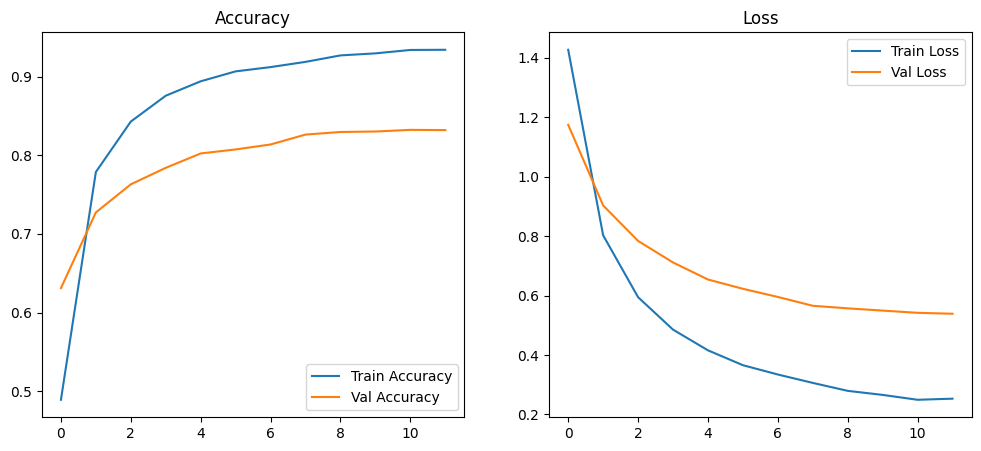

Saved artifact at '/tmp/tmpy56cf7pg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  135352240392720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240390224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240395024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240394640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240393488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352246304016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240393680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240395792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240395408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135352240395216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13535224039195

In [ ]:
 # Pretrained model
pre_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
pre_model.trainable = False

# Classifier head
pre_output = pre_model.output
pre_output = GlobalAveragePooling2D()(pre_output)
predictions = Dense(train_data.num_classes, activation='softmax')(pre_output)

model = Model(inputs=pre_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Early stopping
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Train first phase
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stopping]
)

# Fine-tune last 30 layers
# pre_model.trainable = True
# for layer in pre_model.layers[:-30]:
#     layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=2,
    callbacks=[early_stopping]
)

# Plot accuracy & loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

# Save Model (.h5)
model.save('/content/dataset/NepaliCurrencyDetectorModel.h5')

# Convert to TensorFlow Lite (.tflite)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('/content/dataset/NepaliCurrencyDetectorModel.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Both H5 and TFLite models saved successfully!")
loss, accuracy = model.evaluate(valid_data)
print(f"✅ Validation Accuracy: {accuracy*100:.2f}%")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

class_names = ["fifty", "five", "fivehundred", "hundred", "ten", "thousand", "twenty"]

def check_single_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_arr = image.img_to_array(img) / 255.0
    img_arr = np.expand_dims(img_arr, axis=0)

    prediction = model.predict(img_arr)[0]
    class_idx = np.argmax(prediction)
    confidence = prediction[class_idx]

    print("Predicted Class:", class_names[class_idx])
    print("Confidence:", round(confidence * 100, 2), "%")

check_single_image("/content/dataset/dataset/valid/fifty/fifty_valid_1.jpg")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Class: fifty
Confidence: 96.62 %


105/105 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step


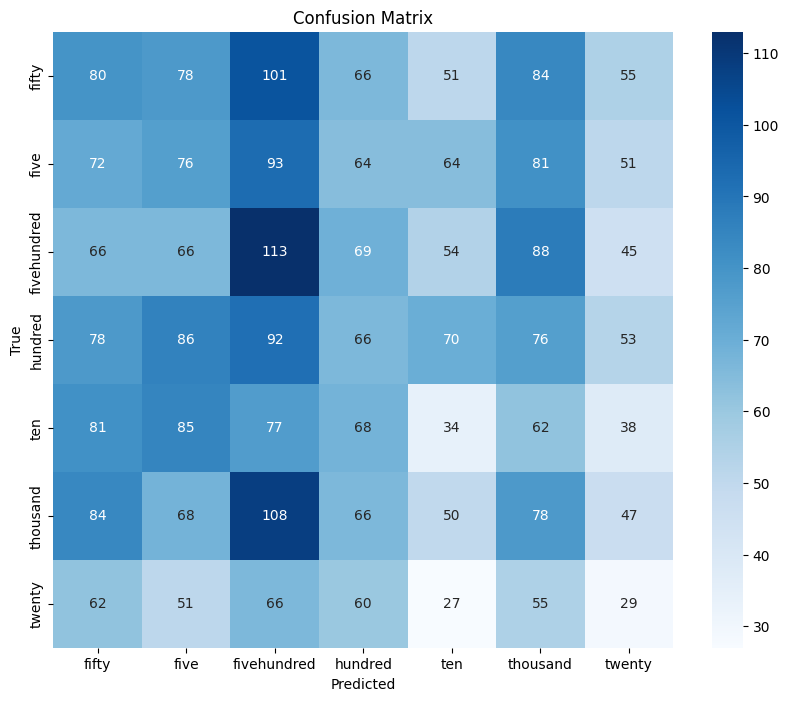

In [27]:

valid_data.reset()

# Predict all validation images
preds = model.predict(valid_data, verbose=1)

y_pred = np.argmax(preds, axis=1)
y_true = valid_data.classes
class_names = list(valid_data.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()